# SIPTA: Modelado Territorial y Cálculo Matemático Exhaustivo del IPT

**Fase PDCO**: DEVELOPMENT → CONTROL | **Sprint**: 2  
**Estándares**: SWEBOK Cap. 2 (Software Design) & Cap. 4 (Testing), DAMA-BOK, ISO/IEC 25010, Clean Code, PEP 8  
**Sistema**: Sistema de Indicadores y Priorización Territorial y Alertas Tempranas (SIPTA)

---

## 🎯 Propósito y Alcance del Cuaderno
Este cuaderno expone **paso a paso y con rigor matemático cómo se calcula cada uno de los Índices de Priorización Territorial (IPT)**, desglosando:
1. **Montaje de Tablas Maestras**: Generación de las 12 tablas temáticas curadas.
2. **Cálculo de Sub-Índices Dimensionales**: Fórmula Min-Max y aplicación de polaridad de necesidad ($s_{i, d} \in [0, 1]$).
3. **Cálculo de los 5 Escenarios de IPT ($[0, 100]$)**:
   - $\text{IPT}_{\text{Base}}$ (7 dimensiones balanceadas, $w_d = 1/7$).
   - $\text{IPT}_{\text{Rangos}}$ (Normalización no paramétrica por percentiles).
   - $\text{IPT}_{\text{SinParques}}$ (6 dimensiones, exclusión de infraestructura IDRD, $w_d = 1/6$).
   - $\text{IPT}_{\text{SinRIVI}}$ (6 dimensiones, exclusión de vendedores informales, $w_d = 1/6$).
   - $\text{IPT}_{\text{SinProxies}}$ (5 dimensiones duras: Educación, Salud, Movilidad, Ambiente y Seguridad, $w_d = 1/5$).
4. **Cálculo del Ranking de Consenso y Nivel de Confianza**: Desempate determinístico DIVIPOLA y consistencia de Top 5.
5. **Exploraciones Analíticas Multidimensionales**: Correlaciones, dispersiones y gráficos de radar/araña.


## 1. Configuración del Entorno y Carga de Módulos Modulares `src/`


In [30]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Resolución de rutas canónicas del workspace
ROOT = Path.cwd().resolve()
if ROOT.name in ["04_modeling", "notebooks"]:
    ROOT = ROOT.parents[1] if ROOT.name == "04_modeling" else ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Configuración estética para gráficos científicos
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8

# Importación de componentes de modelado SIPTA
from src.modeling.calculate_indicators import (
    normalize_min_max,
    build_ipt,
    build_consolidated_locality_metrics,
    calculate_multidimensional_ipt,
    calculate_consensus_priority,
    save_indicator_table,
    DIMENSION_COLUMNS,
)
from src.modeling.domain_indicators import (
    build_all_domain_tables,
    load_unified_territorial_source,
)

print(f"[OK] Módulos de modelado importados correctamente desde: {ROOT}")


[OK] Módulos de modelado importados correctamente desde: C:\Users\ADAN\DataJam_DataOlinguitos_Gen


## 2. Montaje y Generación de las 12 Tablas Maestras por Dominio Territorial

A partir de los datasets crudos y el tablón maestro integrado (`master_localidades.csv`), se construyen y persisten las 12 tablas temáticas en `data/curated/`:


In [31]:
print("Construyendo y exportando las 12 tablas maestras por dominio territorial...")
domain_tables = build_all_domain_tables(export_curated=True)

resumen_dominios = []
for dom_name, df_dom in domain_tables.items():
    resumen_dominios.append({
        "Tabla Maestra": f"{dom_name}.csv",
        "Localidades": len(df_dom),
        "Variables": df_dom.shape[1],
        "Columnas Clave": ", ".join(list(df_dom.columns[:4])) + "...",
    })

df_resumen_dominios = pd.DataFrame(resumen_dominios)
display(df_resumen_dominios)


2026-08-23 21:52:03,050 - INFO - Guardada tabla de dominio: C:\Users\ADAN\DataJam_DataOlinguitos_Gen\data\curated\master_demografia.csv (20 filas, 6 columnas)
2026-08-23 21:52:03,054 - INFO - Guardada tabla de dominio: C:\Users\ADAN\DataJam_DataOlinguitos_Gen\data\curated\master_salud.csv (20 filas, 10 columnas)
2026-08-23 21:52:03,060 - INFO - Guardada tabla de dominio: C:\Users\ADAN\DataJam_DataOlinguitos_Gen\data\curated\master_educacion.csv (20 filas, 11 columnas)
2026-08-23 21:52:03,065 - INFO - Guardada tabla de dominio: C:\Users\ADAN\DataJam_DataOlinguitos_Gen\data\curated\master_movilidad.csv (20 filas, 10 columnas)
2026-08-23 21:52:03,070 - INFO - Guardada tabla de dominio: C:\Users\ADAN\DataJam_DataOlinguitos_Gen\data\curated\master_ambiente.csv (20 filas, 6 columnas)
2026-08-23 21:52:03,075 - INFO - Guardada tabla de dominio: C:\Users\ADAN\DataJam_DataOlinguitos_Gen\data\curated\master_infraestructura.csv (20 filas, 6 columnas)
2026-08-23 21:52:03,080 - INFO - Guardada tabla

Construyendo y exportando las 12 tablas maestras por dominio territorial...


,Tabla Maestra,Localidades,Variables,Columnas Clave
0,master_demografia.csv,20,6,"codigo_localidad, nombre_localidad, codigo_div..."
1,master_salud.csv,20,10,"codigo_localidad, nombre_localidad, codigo_div..."
2,master_educacion.csv,20,11,"codigo_localidad, nombre_localidad, codigo_div..."
3,master_movilidad.csv,20,10,"codigo_localidad, nombre_localidad, codigo_div..."
4,master_ambiente.csv,20,6,"codigo_localidad, nombre_localidad, codigo_div..."
5,master_infraestructura.csv,20,6,"codigo_localidad, nombre_localidad, codigo_div..."
6,master_finanzas.csv,20,9,"codigo_localidad, nombre_localidad, codigo_div..."
7,master_vulnerabilidad_social.csv,20,10,"codigo_localidad, nombre_localidad, codigo_div..."
8,master_seguridad.csv,20,12,"codigo_localidad, nombre_localidad, codigo_div..."
9,master_servicios_publicos.csv,20,15,"codigo_localidad, nombre_localidad, codigo_div..."


## 3. Formulación Matemática: Cómo se Calcula cada Sub-Índice Dimensional ($s_{i, d}$)

Cada dimensión de necesidad territorial $d \in \{1, \dots, 7\}$ se calcula a partir de un indicador empírico $x_{i, d}$ para cada localidad $i \in \{1, \dots, 20\}$.

### Paso 3.1: Normalización Min-Max al Intervalo $[0, 1]$
$$\hat{x}_{i, d} = \frac{x_{i, d} - \min_{k}(x_{k, d})}{\max_{k}(x_{k, d}) - \min_{k}(x_{k, d})}$$

### Paso 3.2: Asignación de Polaridad de Carencia / Necesidad ($s_{i, d}$)
1. **Sentido Inverso (Oferta / Equipamientos / Capacidad)**:
   A mayor disponibilidad de servicio $\implies$ menor carencia territorial:
   $$s_{i, d} = 1 - \hat{x}_{i, d}$$
   *Aplica a*: Educación (`EDU-001`), Salud (`SAL-001`), Movilidad (`MOV-001`), Infraestructura (`INF-001`) y Seguridad (`SEG-001`).

2. **Sentido Directo (Vulnerabilidad / Amenaza / Conflicto)**:
   A mayor presencia del fenómeno $\implies$ mayor carencia o riesgo:
   $$s_{i, d} = \hat{x}_{i, d}$$
   *Aplica a*: Ambiente (`AMB-001`) y Vulnerabilidad Social (`VUL-001`).


In [32]:
# Cargar la matriz consolidada de métricas
metrics_df = build_consolidated_locality_metrics()

# Visualizar la tabla de sub-índices dimensionales normalizados en [0, 1]
cols_dim = ["codigo_localidad", "localidad"] + list(DIMENSION_COLUMNS)
df_subindices = metrics_df[cols_dim].copy()

print("=========================================================================================")
print("SUB-ÍNDICES DIMENSIONALES NORMALIZADOS DE CARENCIA [0 = Menor Carencia, 1 = Mayor Carencia]")
print("=========================================================================================")
display(df_subindices)


SUB-ÍNDICES DIMENSIONALES NORMALIZADOS DE CARENCIA [0 = Menor Carencia, 1 = Mayor Carencia]


,codigo_localidad,localidad,dim_educacion,dim_salud,dim_movilidad,dim_ambiente,dim_infraestructura,dim_vulnerabilidad,dim_seguridad
0,01,USAQUEN,0.961867,0.712209,0.735710,0.054489,0.929326,0.000000,0.911218
1,02,CHAPINERO,1.000000,0.000000,0.743440,0.136099,0.845739,0.172742,0.731416
2,03,SANTA FE,0.897360,0.797979,0.804074,0.113864,0.414941,0.963571,0.676212
3,04,SAN CRISTOBAL,0.840281,0.994006,0.815820,0.013404,0.874021,0.081605,0.900415
4,05,USME,0.770996,0.999926,0.966981,0.024899,0.854670,0.043412,0.930690
5,06,TUNJUELITO,0.721483,0.958774,0.476118,0.381576,0.905507,0.051116,0.905844
6,07,BOSA,0.821091,1.000000,0.529170,0.108343,0.881306,0.016838,0.916554
7,08,KENNEDY,0.878029,0.963047,0.438223,0.106084,0.902400,0.033396,0.914114
8,09,FONTIBON,0.907398,0.905000,0.750879,0.018508,0.892504,0.021944,0.924264
9,10,ENGATIVA,0.889654,0.952732,0.452825,0.052881,0.870386,0.022778,0.946571


## 4. Formulación Matemática de los 5 Escenarios de IPT

El sistema SIPTA calcula **5 variantes metodológicas del IPT** para evaluar la sensibilidad y garantizar robustez frente a sesgos de ponderación o selección de variables:

### 📌 Escenario 1: IPT Base Multidimensional (`ipt_base`, 7 Dimensiones)
Ponderación balanceada uniforme ($w_d = \frac{1}{7} \approx 0.142857$) escalada a $[0, 100]$:
$$\text{IPT}_{\text{Base}, i} = \left( \frac{1}{7} \sum_{d=1}^{7} s_{i, d} \right) \times 100$$

### 📌 Escenario 2: IPT Normalización por Rangos / Percentiles (`ipt_rangos`)
Calcula el orden percentil no paramétrico de cada indicador para eliminar el impacto de valores atípicos (*outliers*):
$$\text{IPT}_{\text{Rangos}, i} = \left( \frac{1}{7} \sum_{d=1}^{7} \text{PercentileRank}(x_{i, d}) \right) \times 100$$

### 📌 Escenario 3: IPT Sin Proxy Parques IDRD (`ipt_sin_proxy`, 6 Dimensiones)
Excluye la dimensión de infraestructura de parques ($w_d = \frac{1}{6}$):
$$\text{IPT}_{\text{SinParques}, i} = \left( \frac{1}{6} \sum_{d \in \{ \text{Edu, Sal, Mov, Amb, Vul, Seg} \}} s_{i, d} \right) \times 100$$

### 📌 Escenario 4: IPT Sin RIVI Vendedores Informales (`ipt_sin_rivi`, 6 Dimensiones)
Excluye la dimensión de vulnerabilidad de economía informal ($w_d = \frac{1}{6}$):
$$\text{IPT}_{\text{SinRIVI}, i} = \left( \frac{1}{6} \sum_{d \in \{ \text{Edu, Sal, Mov, Amb, Inf, Seg} \}} s_{i, d} \right) \times 100$$

### 📌 Escenario 5: IPT Sin Proxies (`ipt_sin_proxy_ni_rivi`, 5 Dimensiones Duras)
Retiene únicamente las 5 dimensiones con registro administrativo duro ($w_d = \frac{1}{5} = 0.20$):
$$\text{IPT}_{\text{SinProxies}, i} = \left( \frac{1}{5} \sum_{d \in \{ \text{Edu, Sal, Mov, Amb, Seg} \}} s_{i, d} \right) \times 100$$


In [33]:
# Tabla comparativa de los 5 puntajes IPT calculados para las 20 localidades
ipt_df = calculate_multidimensional_ipt(metrics_df)

cols_escenarios = [
    "codigo_localidad",
    "localidad",
    "ipt_base",
    "ipt_rangos",
    "ipt_sin_proxy",
    "ipt_sin_rivi",
    "ipt_sin_proxy_ni_rivi",
]

df_comparativa_ipt = metrics_df[cols_escenarios].copy()
df_comparativa_ipt.columns = [
    "Código", "Localidad", "IPT Base (7D)", "IPT Rangos (7D)",
    "IPT Sin Parques (6D)", "IPT Sin RIVI (6D)", "IPT Sin Proxies (5D)"
]

print("=========================================================================================")
print("PUNTAJES OBTENIDOS EN LOS 5 ESCENARIOS METODOLÓGICOS DEL IPT (ESCALA 0 - 100)")
print("=========================================================================================")
display(df_comparativa_ipt.round(2))


PUNTAJES OBTENIDOS EN LOS 5 ESCENARIOS METODOLÓGICOS DEL IPT (ESCALA 0 - 100)


,Código,Localidad,IPT Base (7D),IPT Rangos (7D),IPT Sin Parques (6D),IPT Sin RIVI (6D),IPT Sin Proxies (5D)
0,01,USAQUEN,61.50,51.50,56.26,71.75,67.51
1,02,CHAPINERO,51.85,54.14,46.39,57.61,52.22
2,03,SANTA FE,66.69,49.62,70.88,61.74,65.79
3,04,SAN CRISTOBAL,64.57,55.64,60.76,73.97,71.28
4,05,USME,65.59,58.65,62.28,75.80,73.87
5,06,TUNJUELITO,62.86,54.89,58.25,72.49,68.88
6,07,BOSA,61.05,55.26,56.53,70.94,67.50
7,08,KENNEDY,60.50,56.77,55.55,70.03,65.99
8,09,FONTIBON,63.15,56.77,58.80,73.31,70.12
9,10,ENGATIVA,59.83,53.38,55.29,69.42,65.89


## 5. Cálculo del Ranking de Consenso y Nivel de Confianza

Para evitar decisiones basadas en un único escenario sensible a ponderaciones, se calcula la **Priorización de Consenso**:

### 1. Ranking Promedio entre Escenarios ($\overline{R}_i$)
$$\overline{R}_i = \frac{1}{K} \sum_{k=1}^{K} R_{k, i}, \quad \text{donde } K = 5$$

### 2. Regla de Desempate Determinística
El orden final se determina ordenando por:
1. $\overline{R}_i$ (Ascendente - Menor promedio = Mayor prioridad).
2. $\text{IPT}_{\text{Base}}$ (Descendente - Mayor puntaje base).
3. Código DIVIPOLA `codigo_localidad` (Ascendente - Desempate institucional determinístico).

### 3. Estratificación por Niveles de Prioridad
- **Alta Prioridad**: Posiciones 1 a 5 ($R_{\text{consenso}} \le 5$).
- **Media-Alta**: Posiciones 6 a 10 ($6 \le R_{\text{consenso}} \le 10$).
- **Media**: Posiciones 11 a 15 ($11 \le R_{\text{consenso}} \le 15$).
- **Baja**: Posiciones 16 a 20 ($16 \le R_{\text{consenso}} \le 20$).

### 4. Métrica de Confianza Analítica
Basada en la consistencia de pertenencia al Top 5 en los 5 escenarios:
- **Alta**: Si la localidad aparece $\ge 4$ veces en el Top 5.
- **Media**: Si aparece entre 2 y 3 veces en el Top 5.
- **Baja**: Si aparece $\le 1$ vez.


In [34]:
ranking_cols = [c for c in metrics_df.columns if c.startswith("ranking_ipt_")]
prioritized_df = calculate_consensus_priority(ipt_df, ranking_cols=ranking_cols)

cols_finales = [
    "codigo_localidad",
    "localidad",
    "IPT_MULTIDIMENSIONAL",
    "RANKING_PRIORIDAD",
    "ranking_promedio_escenarios",
    "ranking_consenso",
    "nivel_prioridad_consenso",
    "apariciones_top5",
    "confianza_priorizacion",
]

df_priorizacion_final = prioritized_df[cols_finales].sort_values("ranking_consenso").reset_index(drop=True)

print("=========================================================================================")
print("MATRIZ OFICIAL DE PRIORIZACIÓN DE CONSENSO (TODAS LAS LOCALIDADES)")
print("=========================================================================================")
display(df_priorizacion_final)


MATRIZ OFICIAL DE PRIORIZACIÓN DE CONSENSO (TODAS LAS LOCALIDADES)


,codigo_localidad,localidad,IPT_MULTIDIMENSIONAL,RANKING_PRIORIDAD,ranking_promedio_escenarios,ranking_consenso,nivel_prioridad_consenso,apariciones_top5,confianza_priorizacion
0,05,USME,65.593898,3,2.2,1,Alta,5,Alta
1,18,RAFAEL URIBE URIBE,70.356637,1,3.2,2,Alta,4,Alta
2,11,SUBA,64.724741,4,4.0,3,Alta,4,Alta
3,04,SAN CRISTOBAL,64.565046,5,5.0,4,Alta,5,Alta
4,19,CIUDAD BOLIVAR,64.464025,6,6.0,5,Alta,3,Media
5,09,FONTIBON,63.149950,7,6.2,6,Media-alta,1,Baja
6,06,TUNJUELITO,62.863100,8,7.8,7,Media-alta,0,Baja
7,03,SANTA FE,66.685743,2,9.0,8,Media-alta,2,Media
8,07,BOSA,61.047178,10,9.2,9,Media-alta,0,Baja
9,08,KENNEDY,60.504188,12,9.8,10,Media-alta,1,Baja


## 6. Exploraciones Analíticas y Visualizaciones del Modelo Territorial


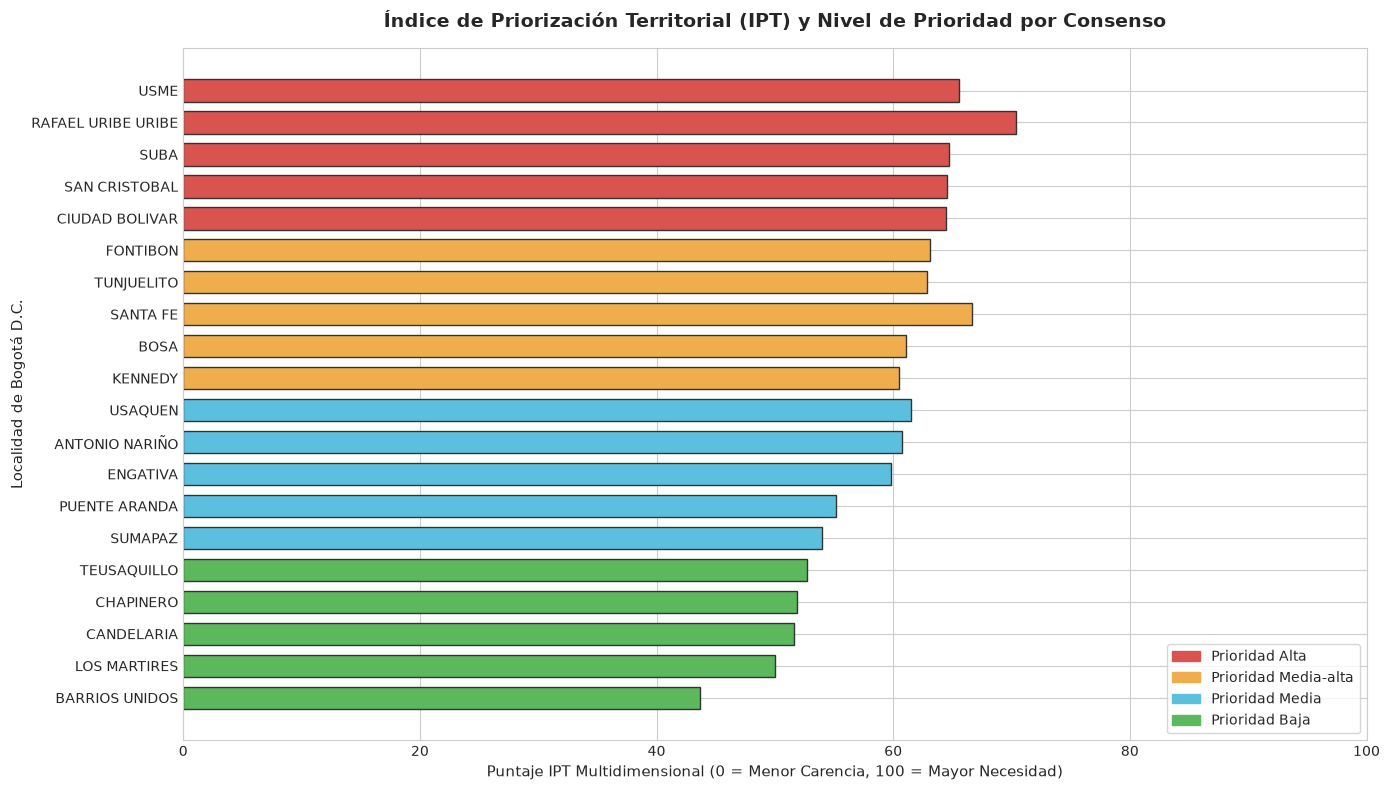

In [35]:
# 1. Gráfico de Barras de Priorización Territorial
plt.figure(figsize=(14, 8))

colores_prioridad = {
    "Alta": "#d9534f",
    "Media-alta": "#f0ad4e",
    "Media": "#5bc0de",
    "Baja": "#5cb85c",
}

df_plot = prioritized_df.sort_values("ranking_consenso", ascending=True)
bar_colors = [colores_prioridad.get(p, "#999999") for p in df_plot["nivel_prioridad_consenso"]]

bars = plt.barh(df_plot["localidad"][::-1], df_plot["IPT_MULTIDIMENSIONAL"][::-1], color=bar_colors[::-1], edgecolor="#333333", height=0.7)

plt.title("Índice de Priorización Territorial (IPT) y Nivel de Prioridad por Consenso", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Puntaje IPT Multidimensional (0 = Menor Carencia, 100 = Mayor Necesidad)", fontsize=11)
plt.ylabel("Localidad de Bogotá D.C.", fontsize=11)
plt.xlim(0, 100)

handles = [plt.Rectangle((0,0),1,1, color=colores_prioridad[k]) for k in ["Alta", "Media-alta", "Media", "Baja"]]
plt.legend(handles, ["Prioridad Alta", "Prioridad Media-alta", "Prioridad Media", "Prioridad Baja"], loc="lower right", frameon=True)

plt.tight_layout()
plt.show()


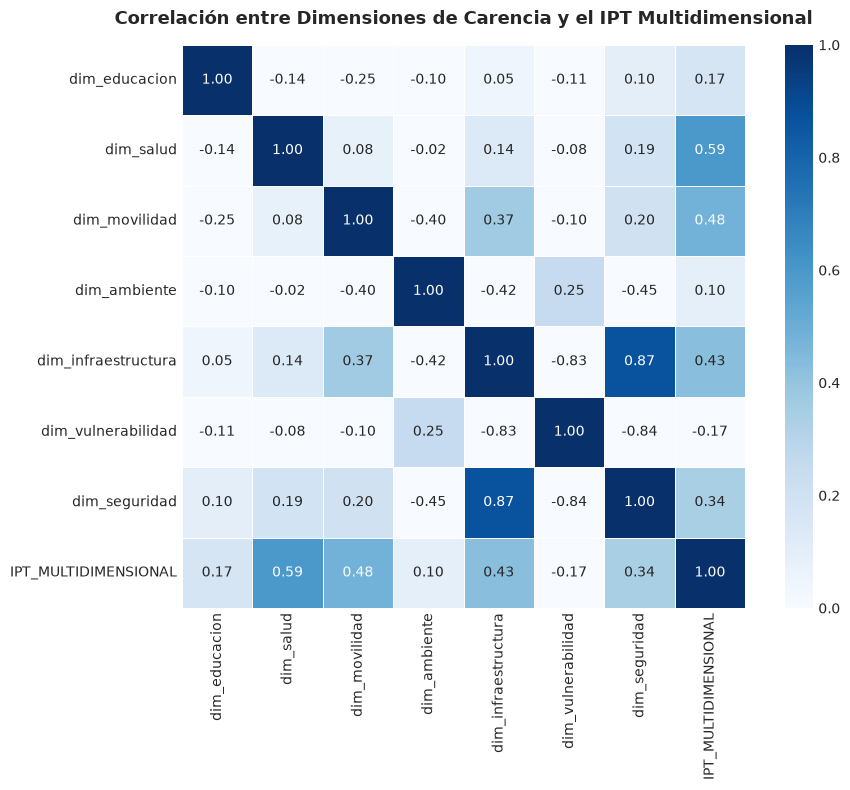

In [36]:
# 2. Mapa de Calor de Correlaciones Dimensionales
dim_cols_plot = list(DIMENSION_COLUMNS) + ["IPT_MULTIDIMENSIONAL"]
df_dim_corr = prioritized_df[dim_cols_plot].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(df_dim_corr, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, square=True, linewidths=0.5)
plt.title("Correlación entre Dimensiones de Carencia y el IPT Multidimensional", fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


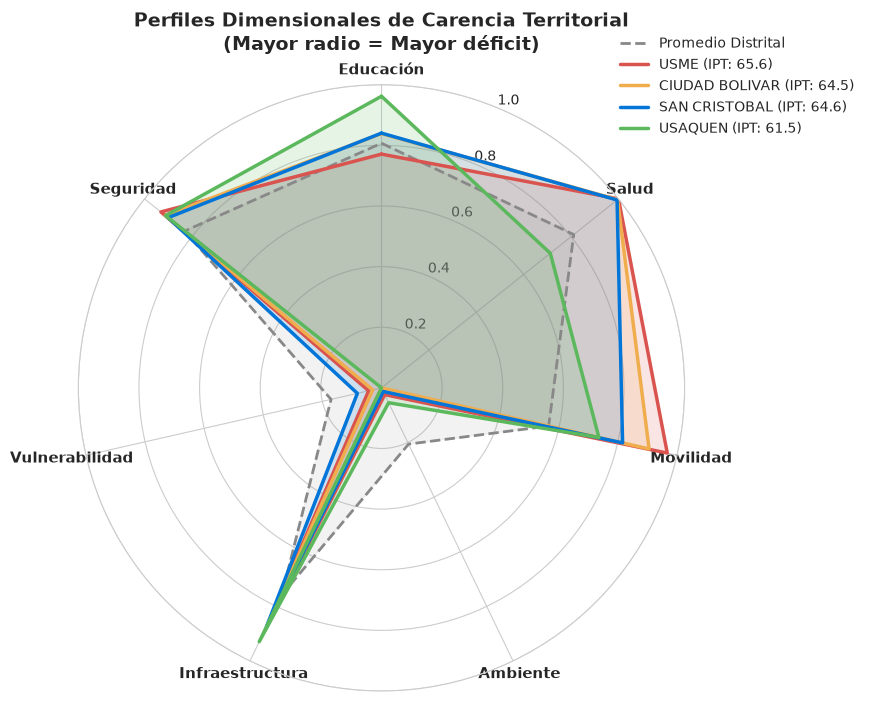

In [37]:
# 3. Gráfico Radar / Spider Chart de Perfiles Dimensionales
def plot_radar_comparison(df, localidades_sel):
    categories = [
        "Educación", "Salud", "Movilidad", "Ambiente",
        "Infraestructura", "Vulnerabilidad", "Seguridad"
    ]
    dim_cols = [
        "dim_educacion", "dim_salud", "dim_movilidad", "dim_ambiente",
        "dim_infraestructura", "dim_vulnerabilidad", "dim_seguridad"
    ]
    
    num_vars = len(categories)
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]
    
    fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
    
    # Promedio Distrital
    avg_values = df[dim_cols].mean().values.tolist()
    avg_values += avg_values[:1]
    ax.plot(angles, avg_values, color="#888888", linewidth=2, linestyle="--", label="Promedio Distrital")
    ax.fill(angles, avg_values, color="#888888", alpha=0.1)
    
    # Localidades seleccionadas
    colores_loc = ["#d9534f", "#f0ad4e", "#0275d8", "#5cb85c"]
    for idx, loc_name in enumerate(localidades_sel):
        loc_row = df[df["localidad"] == loc_name]
        if not loc_row.empty:
            values = loc_row[dim_cols].values[0].tolist()
            values += values[:1]
            color = colores_loc[idx % len(colores_loc)]
            ax.plot(angles, values, color=color, linewidth=2.5, label=f"{loc_name} (IPT: {loc_row['IPT_MULTIDIMENSIONAL'].values[0]:.1f})")
            ax.fill(angles, values, color=color, alpha=0.15)
            
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, size=11, fontweight='bold')
    ax.set_ylim(0, 1)
    ax.set_title("Perfiles Dimensionales de Carencia Territorial\n(Mayor radio = Mayor déficit)", size=14, fontweight='bold', pad=25)
    plt.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
    plt.tight_layout()
    plt.show()

plot_radar_comparison(prioritized_df, ["USME", "CIUDAD BOLIVAR", "SAN CRISTOBAL", "USAQUEN"])


## 7. Exportación y Validación de Entregables Curados (`data/curated/`)


In [38]:
curated_dir = ROOT / "data" / "curated"
curated_dir.mkdir(parents=True, exist_ok=True)

# Guardar archivos curados
path_priorizacion = curated_dir / "ipt_priorizacion_localidades.csv"
prioritized_df.to_csv(path_priorizacion, index=False, encoding="utf-8-sig")

path_modelo = curated_dir / "ipt_modelo_localidad.csv"
prioritized_df.to_csv(path_modelo, index=False, encoding="utf-8-sig")

print("============================================================")
print("ARTEFACTOS CURADOS EXPORTADOS EXITOSAMENTE")
print(f"  • Priorización: {path_priorizacion} ({len(prioritized_df)} localidades)")
print(f"  • Modelo IPT:   {path_modelo} ({prioritized_df.shape[1]} columnas)")
print("============================================================")


ARTEFACTOS CURADOS EXPORTADOS EXITOSAMENTE
  • Priorización: C:\Users\ADAN\DataJam_DataOlinguitos_Gen\data\curated\ipt_priorizacion_localidades.csv (20 localidades)
  • Modelo IPT:   C:\Users\ADAN\DataJam_DataOlinguitos_Gen\data\curated\ipt_modelo_localidad.csv (95 columnas)
